## Equation to solve
$$
p + (1-f_{FD})N_D - n - N_A = 0\\
n = N_C*e^{-\frac{E_c-E_f}{kT}}\\
p = \frac{n_i^2}{n}\\
$$

$$
- N_C^2*e^{-2\frac{E_c-E_f}{kT}} + N_d*N_C*\frac{e^{\frac{E_d-E_f}{kT}}}{1+e^{\frac{E_d-E_f}{kT}}}*e^{\frac{E_c-E_f}{kT}} + (N_C*N_V*e^{-\frac{E_g}{kT}} - N_a) = 0
$$


C:\Users\Franek\AppData\Local\Temp\ipykernel_12832\1245108158.py:25: RuntimeWarning: overflow encountered in exp
  Nd_plus = Nd_cm3 / (1.0 + np.exp((Ef - E_D) / kT))  # g_D = 1
C:\Users\Franek\AppData\Local\Temp\ipykernel_12832\1245108158.py:23: RuntimeWarning: overflow encountered in exp
  n = N_C * np.exp(-(E_C - Ef) / kT)
C:\Users\Franek\AppData\Local\Temp\ipykernel_12832\1245108158.py:24: RuntimeWarning: divide by zero encountered in divide
  p = ni2 / n
C:\Users\Franek\AppData\Local\Temp\ipykernel_12832\1245108158.py:29: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  return float(fsolve(neutrality, x0=Ef0, xtol=1e-12, maxfev=200)[0])


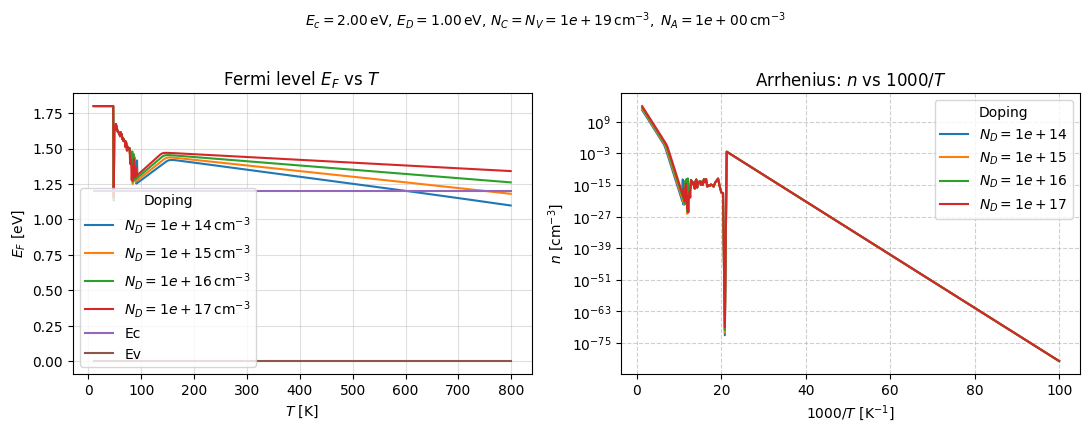

In [ ]:
from cProfile import label
import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt

# ---- Physical constants / parameters ----
K_B_EV_PER_K = 8.617333262145e-5  # eV/K

N_C = 1e19  # [cm^-3]
N_V = 1e19  # [cm^-3]
E_C = 1.2  # Ec [eV]  (Ev=0 -> Eg = Ec)
E_D = 1.0  # donor level (from Ev) [eV]
N_A = 1 # acceptors [cm^-3]
ND_LIST = [1e14, 1e15, 1e16, 1e17]  # donors to sweep [cm^-3]


# ---- Solver: charge neutrality p + N_D^+ - n - N_A = 0 solved for Ef ----
def fermi_level_eV(T_K: float, Nd_cm3: float) -> float:
    kT = K_B_EV_PER_K * T_K
    ni2 = N_C * N_V * np.exp(-E_C / kT)  # ni^2 = Nc Nv exp(-Eg/kT), Eg=Ec

    def neutrality(Ef: float) -> float:
        n = N_C * np.exp(-(E_C - Ef) / kT)
        p = ni2 / n
        Nd_plus = Nd_cm3 / (1.0 + np.exp((Ef - E_D) / kT))  # g_D = 1
        return p + Nd_plus - n - N_A

    Ef0 = E_C - 0.2  # simple initial guess
    return float(fsolve(neutrality, x0=Ef0, xtol=1e-12, maxfev=200)[0])


# ---- Temperature grid (avoid T=0) ----
T_start,T_stop,Step = 100,800,1
Ts = np.arange(T_start,T_stop,Step)  # K
invT1000 = 1000.0 / Ts  # K^-1

# ---- Plots side by side ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))

for Nd in ND_LIST:
    Ef_vals = np.array([fermi_level_eV(T, Nd) for T in Ts])
    n_vals = N_C * np.exp(-(E_C - Ef_vals) / (K_B_EV_PER_K * Ts))

    # Left: Ef vs T
    ax1.plot(Ts, Ef_vals, label=rf"$N_D={Nd:.0e}\,\mathrm{{cm^{{-3}}}}$")

    # Right: Arrhenius n vs 1000/T (ensure increasing x)
    order = np.argsort(invT1000)
    ax2.semilogy(invT1000[order], n_vals[order], label=rf"$N_D={Nd:.0e}$")

# Formatting
ax1.plot(Ts,[1.2 for _ in Ts],label="Ec")
ax1.plot(Ts,[0 for _ in Ts],label="Ev")
ax1.set_title(r"Fermi level $E_F$ vs $T$")
ax1.set_xlabel(r"$T$ [K]")
ax1.set_ylabel(r"$E_F$ [eV]")
ax1.legend(title="Doping")
ax1.grid(True, alpha=0.4)

ax2.set_title(r"Arrhenius: $n$ vs $1000/T$")
ax2.set_xlabel(r"$1000/T$ [$\mathrm{K}^{-1}$]")
ax2.set_ylabel(r"$n$ [$\mathrm{cm}^{-3}$]")
ax2.legend(title="Doping")
ax2.grid(True, which="both", ls="--", alpha=0.6)

fig.suptitle(
    rf"$E_c={E_C:.2f}\,$eV, $E_D={E_D:.2f}\,$eV, "
    rf"$N_C=N_V={N_C:.0e}\,\mathrm{{cm^{{-3}}}},\; N_A={N_A:.0e}\,\mathrm{{cm^{{-3}}}}$",
    y=1.02,
    fontsize=10,
)
fig.tight_layout()
plt.show()